This is the first file to run

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
DATA_PATH = Path("../data/raw/2017-2018 TrainSet.xlsx")  # adjust if your structure differs
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Data types:\n", df.dtypes)

Shape: (178, 17)
Data types:
 Year              int64
Index No.           str
FinalGPA        float64
S1              float64
S2              float64
S3              float64
S4              float64
S5              float64
S6              float64
S7              float64
S8              float64
Department          str
Zscore          float64
Gender              str
EnglishMarks    float64
District            str
MediumAL            str
dtype: object


In [3]:
df.head()

,Year,Index No.,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Department,Zscore,Gender,EnglishMarks,District,MediumAL
0,2017,176096J,3.88,3.76,3.98,3.86,3.80,3.89,3.89,3.79,3.99,BA,1.8487,F,66.0,Badulla,S
1,2017,176095F,3.67,3.58,3.28,3.64,3.75,3.34,4.02,3.88,3.85,BA,1.5718,M,82.0,Anuradhapura,E
2,2017,176094C,2.74,2.90,3.41,2.74,2.26,1.59,3.02,2.99,2.71,FSM,1.6005,M,NaN,Colombo,S
3,2017,176093X,3.36,3.35,3.00,3.11,3.05,2.59,3.91,3.84,3.90,BPM,1.7060,F,92.0,Ratnapura,S
4,2017,176092T,3.83,3.49,3.73,3.65,4.07,3.85,4.02,4.05,3.89,BA,1.5602,F,76.0,Kalutara,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          178 non-null    int64  
 1   Index No.     178 non-null    str    
 2   FinalGPA      178 non-null    float64
 3   S1            178 non-null    float64
 4   S2            178 non-null    float64
 5   S3            178 non-null    float64
 6   S4            178 non-null    float64
 7   S5            178 non-null    float64
 8   S6            178 non-null    float64
 9   S7            178 non-null    float64
 10  S8            178 non-null    float64
 11  Department    178 non-null    str    
 12  Zscore        178 non-null    float64
 13  Gender        178 non-null    str    
 14  EnglishMarks  172 non-null    float64
 15  District      178 non-null    str    
 16  MediumAL      178 non-null    str    
dtypes: float64(11), int64(1), str(5)
memory usage: 27.1 KB


In [5]:
df.isna().sum().sort_values(ascending=False)


EnglishMarks    6
Year            0
Index No.       0
S1              0
FinalGPA        0
S3              0
S4              0
S5              0
S2              0
S6              0
S7              0
Department      0
S8              0
Zscore          0
Gender          0
District        0
MediumAL        0
dtype: int64

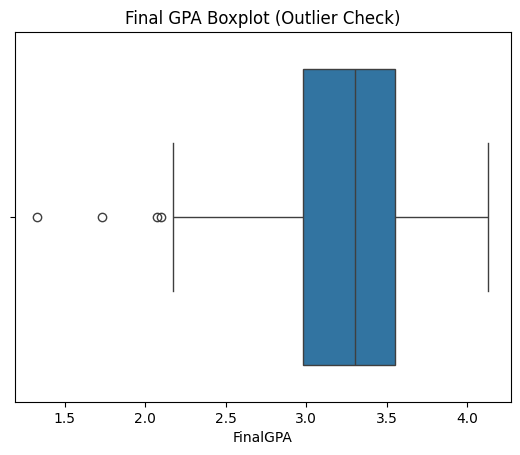

,Year,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Zscore,EnglishMarks
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,172.000000
mean,2017.522472,3.252921,3.149101,3.115899,3.140393,3.265899,3.119382,3.501854,3.354101,3.321629,1.561094,52.860465
std,0.500904,0.458433,0.479365,0.546103,0.574659,0.527613,0.631312,0.545830,0.622927,0.616933,0.126348,20.697861
min,2017.000000,1.330000,1.790000,1.290000,1.150000,0.490000,0.000000,0.000000,0.000000,0.000000,1.029400,3.000000
25%,2017.000000,2.980000,2.792500,2.707500,2.740000,2.982500,2.762500,3.345000,3.120000,3.150000,1.521725,41.000000
50%,2018.000000,3.300000,3.160000,3.180000,3.195000,3.355000,3.210000,3.590000,3.515000,3.420000,1.572250,54.000000
75%,2018.000000,3.547500,3.490000,3.480000,3.610000,3.607500,3.540000,3.840000,3.720000,3.680000,1.615750,67.000000
max,2018.000000,4.130000,4.120000,4.200000,4.140000,4.200000,4.130000,4.110000,4.080000,4.130000,2.269300,92.000000


In [6]:
# print(df[["FinalGPA", "Zscore", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8","EnglishMarks"]].describe())

plt.figure()
sns.boxplot(x=df["FinalGPA"])
plt.title("Final GPA Boxplot (Outlier Check)")
plt.show()

df.describe()

In [7]:
def ClassCounts(FinalGPA):
    if FinalGPA <= 1.99:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "High"

df["PerfGroup"] = df["FinalGPA"].apply(ClassCounts)
print(df["PerfGroup"].value_counts())

pd.crosstab(df["Year"], df["PerfGroup"])


PerfGroup
Second Upper    61
Pass            44
Second Lower    43
High            28
Fail             2
Name: count, dtype: int64


PerfGroup,Fail,High,Pass,Second Lower,Second Upper
Year,,,,,
2017,1,12,25,18,29
2018,1,16,19,25,32


Based on above counts:
Pass and fail are underperforming
Second Lower is Average
Second upper and first class is Performing

In [8]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.00:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "First class"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Second Upper    61
Pass            44
Second Lower    43
First class     28
Fail             2
Name: count, dtype: int64


In [9]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.99:
        return "Underperforming"
    elif FinalGPA <= 3.29:
        return "Average"
    else:
        return "Performing"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Performing         89
Underperforming    46
Average            43
Name: count, dtype: int64


In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

for c in cat_cols[1:]:
    print("\n")
    print(df[c].value_counts(dropna=False).head(20))

Categorical columns: ['Index No.', 'Department', 'Gender', 'District', 'MediumAL', 'PerfGroup']


Department
BPM    81
BA     66
FSM    31
Name: count, dtype: int64


Gender
F    108
M     70
Name: count, dtype: int64


District
Colombo         42
Gampaha         17
Kalutara        12
Matara          10
Kurunegala       9
Kandy            9
Anuradhapura     8
Ratnapura        7
Galle            7
Badulla          6
Kegalle          6
Puttalam         5
Nuwaraeliya      5
Batticaloa       5
Badulla          5
Ampara           4
Monaragala       3
Hambantota       3
Mannar           2
Polonnaruwa      2
Name: count, dtype: int64


MediumAL
S    143
T     22
E     13
Name: count, dtype: int64


PerfGroup
Performing         89
Underperforming    46
Average            43
Name: count, dtype: int64


C:\Users\saw\AppData\Local\Temp\ipykernel_56868\3693009448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [11]:
count = (df[[f"S{i}" for i in range(1,9)]] == 0).sum()
print('Count of zero values in each semester column:')
print(count)

Count of zero values in each semester column:
S1    0
S2    0
S3    0
S4    0
S5    2
S6    2
S7    3
S8    3
dtype: int64


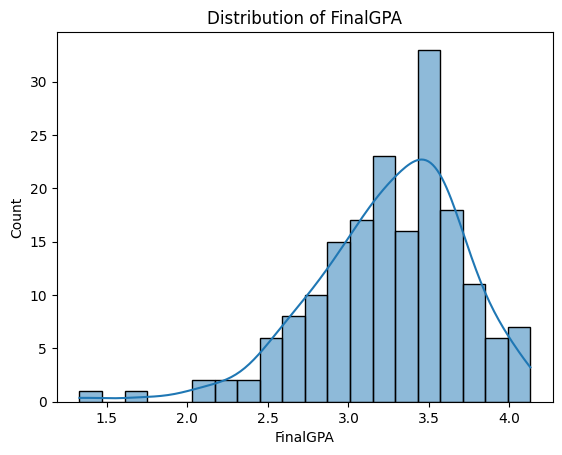

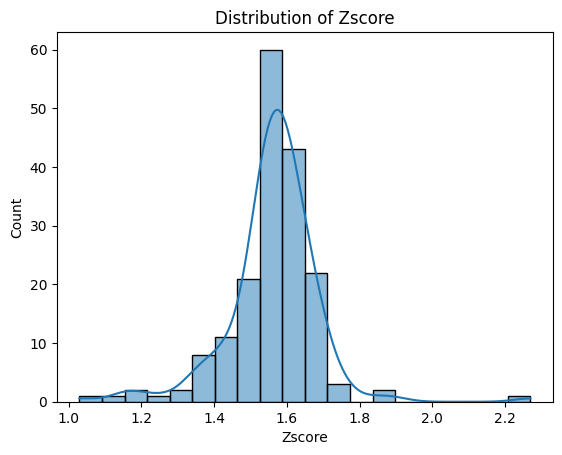

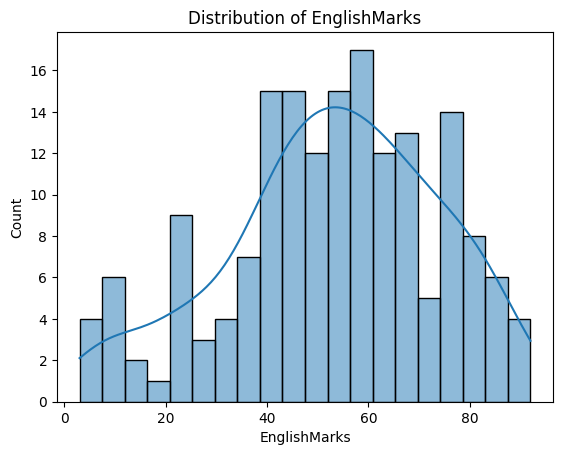

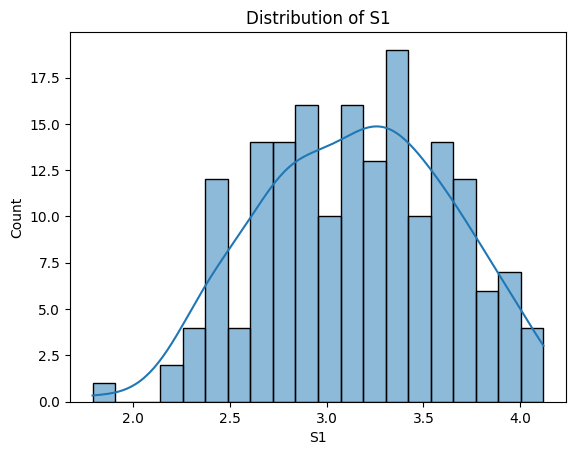

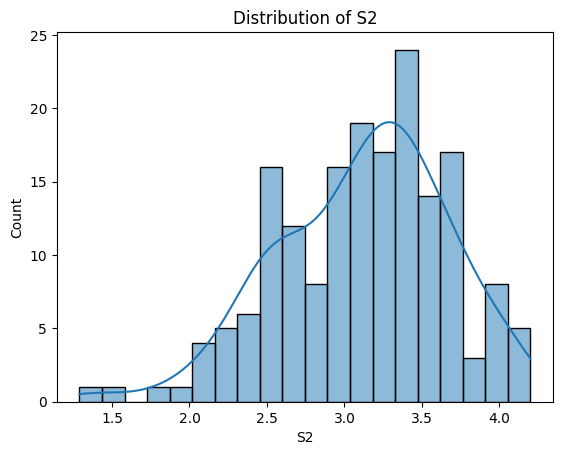

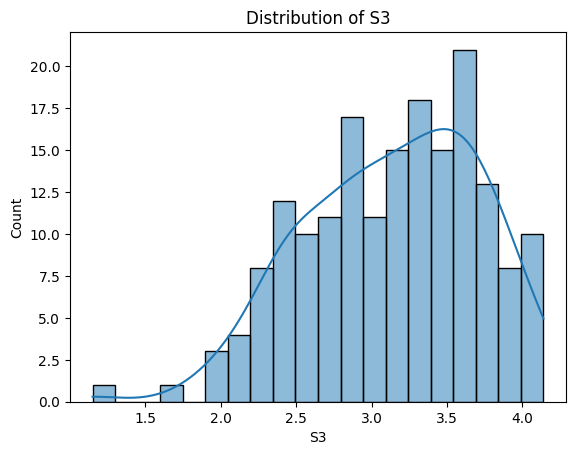

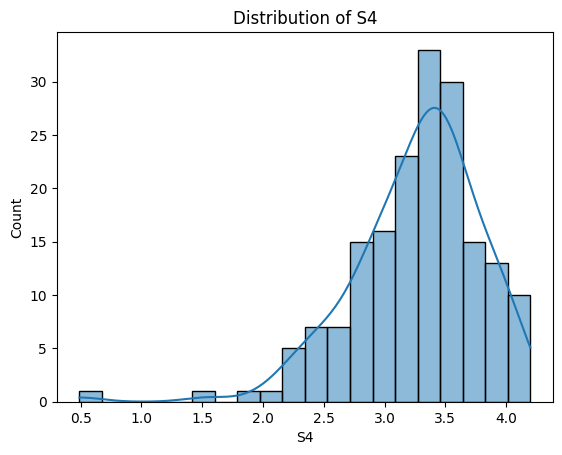

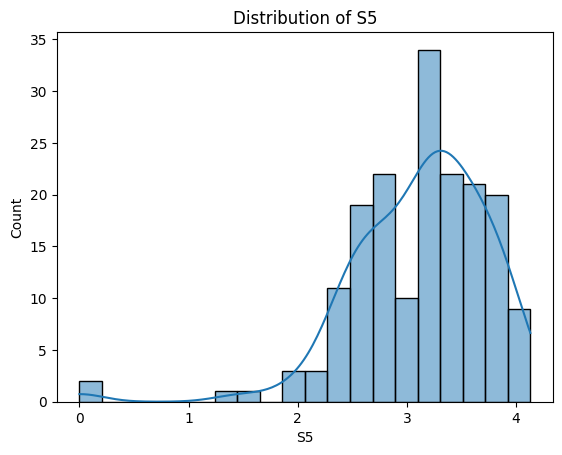

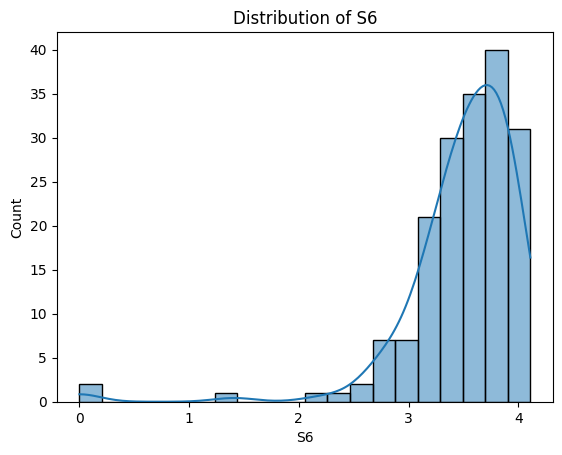

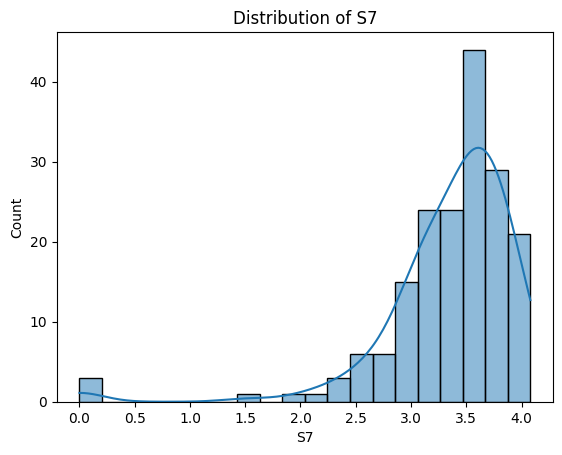

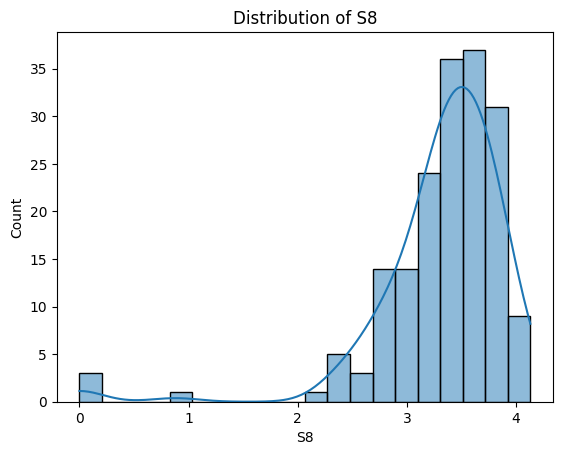

In [12]:
num_pre_cols = ["FinalGPA", "Zscore", "EnglishMarks","S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

for col in num_pre_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

In [13]:
for col in num_pre_cols:
    print(col, df[col].skew())

FinalGPA -0.8727929202112025
Zscore -0.04511614430904616
EnglishMarks -0.3984732037885794
S1 -0.096572228998873
S2 -0.4767994906136667
S3 -0.4185320878300991
S4 -1.2286483991547101
S5 -1.5329309554784167
S6 -3.4728292421282294
S7 -2.9363644795324344
S8 -3.0486993610441573


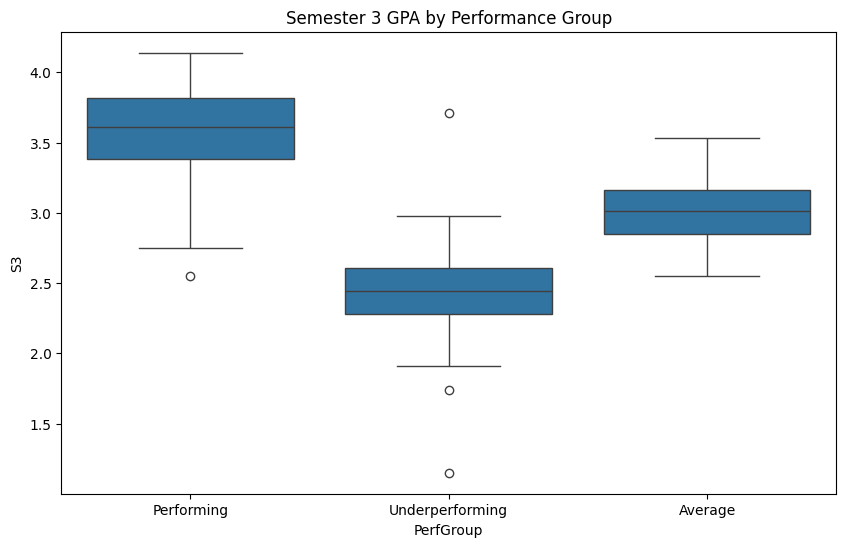

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S3"
)
plt.title("Semester 3 GPA by Performance Group")
plt.show()

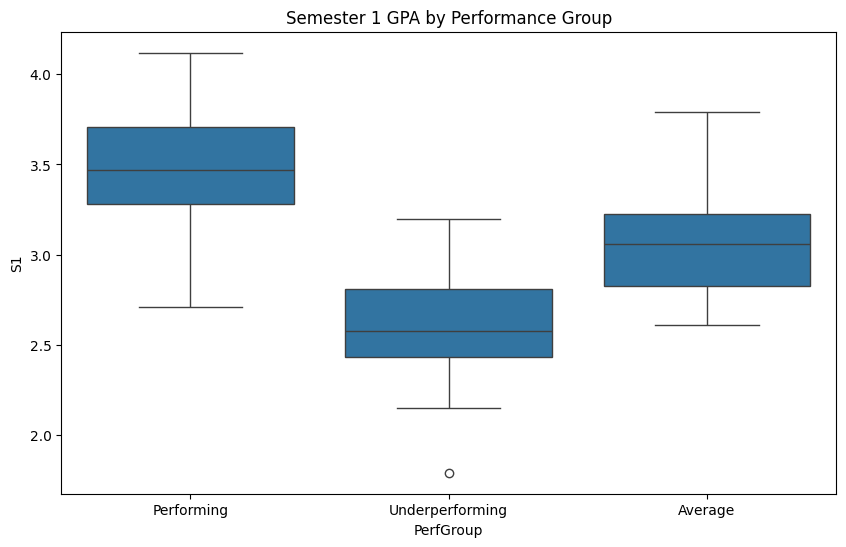

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S1"
)
plt.title("Semester 1 GPA by Performance Group")
plt.show()

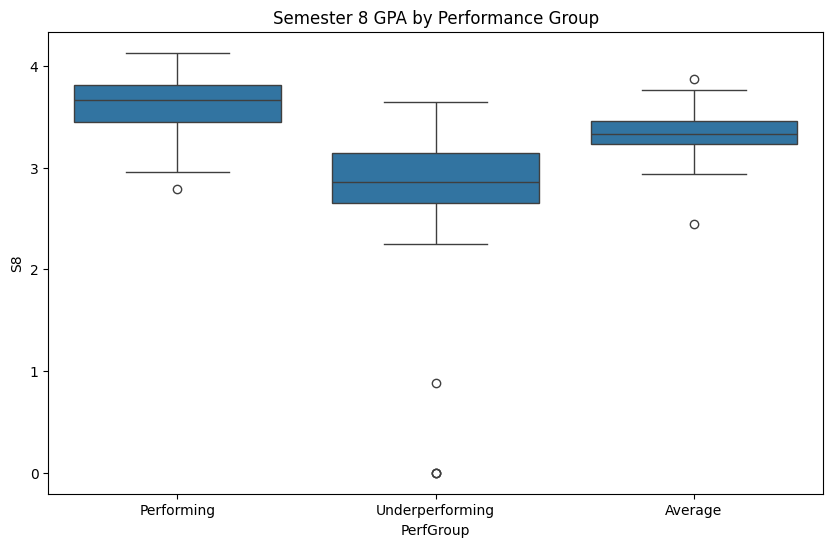

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S8"
)
plt.title("Semester 8 GPA by Performance Group")
plt.show()

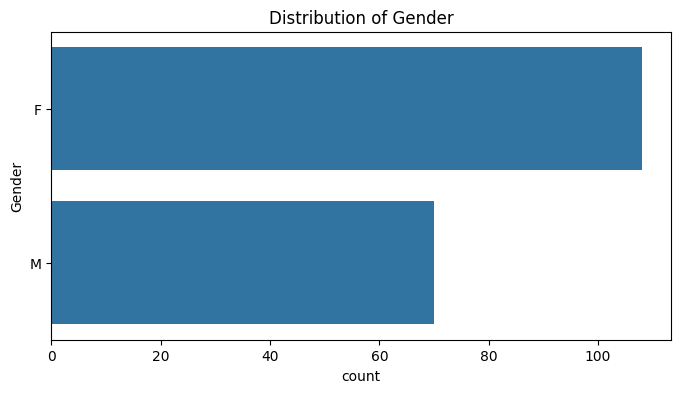

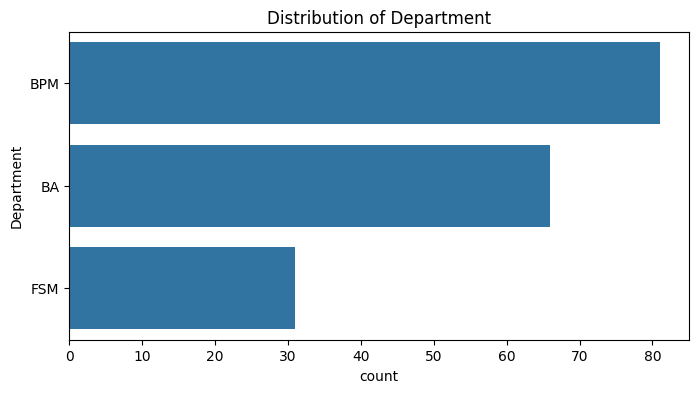

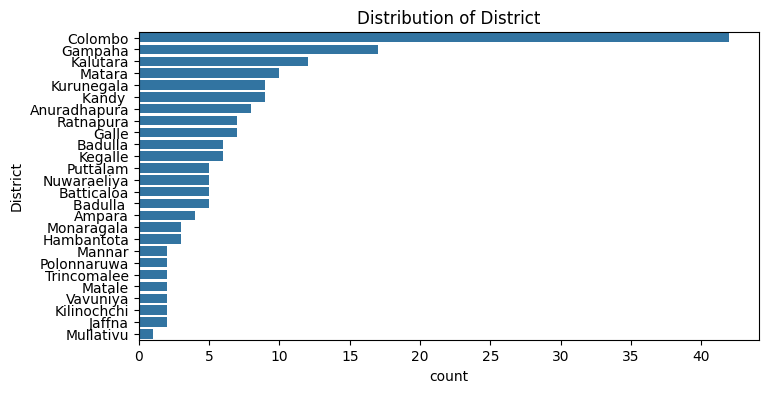

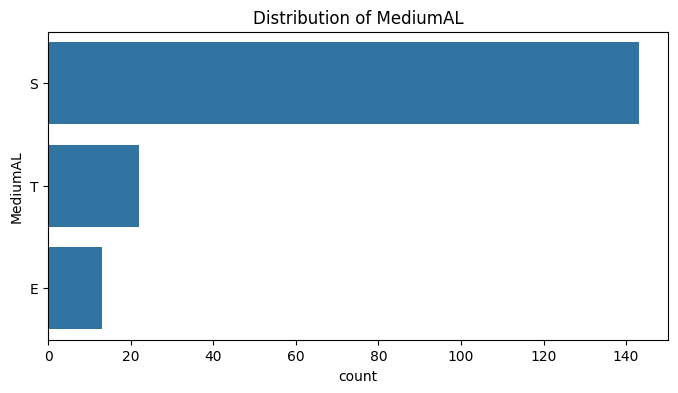

In [17]:
cat_cols = ["Gender", "Department", "District", "MediumAL"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

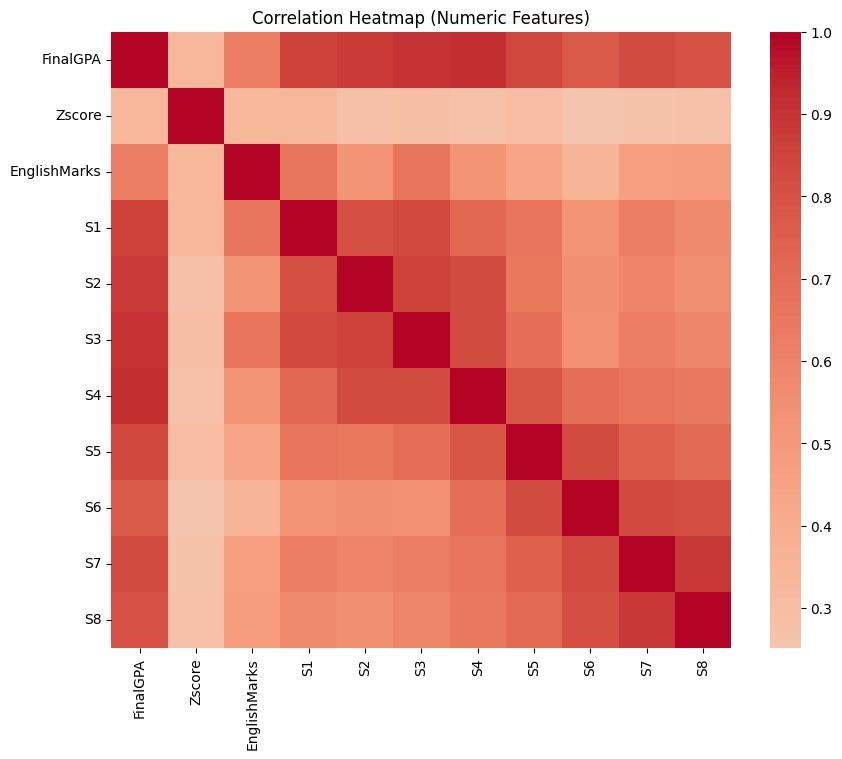

In [18]:
num_cols_for_corr = ["FinalGPA", "Zscore", "EnglishMarks", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[num_cols_for_corr].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()